In [2]:
# Cell 1 – Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings("ignore")

CELL_COL    = "CO_DN"
RAW_FILE    = "../data/4G raw KPI Cell wise17th_June'26.xlsb"
OUTPUT_FILE = "../outputs/KPI_Failure_Tracker.xlsx"

def short_cell_name(co_dn):
    """
    Input : PLMN-PLMN/MRBTS-803406/LNBTS-803406/LNCEL-41
    Output: LNBTS-803406_LNCEL-41
    """
    parts = str(co_dn).split("/")
    if len(parts) >= 2:
        return f"{parts[-2]}_{parts[-1]}"
    return str(co_dn)

# Your 5 KPIs with exact column names and thresholds
KPI_CONFIG = [
    {
        "col"      : "ERAB Drop Rate_Radio_Nokia_VeMr",
        "label"    : "Drop Rate",
        "direction": "high",   # fails when HIGH
        "threshold": 0.5,
    },
    {
        "col"      : "E2E Call Setup Success Rate_Nokia_VeMr",
        "label"    : "E2E CSSR",
        "direction": "low",    # fails when LOW
        "threshold": 99.5,
    },
    {
        "col"      : "VoLTE Call Setup Success Rate_Nokia_VeMr",
        "label"    : "VoLTE CSSR",
        "direction": "low",
        "threshold": 99.5,
    },
    {
        "col"      : "Average CQI_Nokia_VeMr",
        "label"    : "CQI",
        "direction": "low",
        "threshold": 7.0,
    },
    {
        "col"      : "Nokia_LTE_DL_User_Throughput_Mbps",
        "label"    : "Avg Thpr",
        "direction": "low",
        "threshold": 3.0,
    },
]

print("✅ Setup done")
print(f"   Tracking {len(KPI_CONFIG)} KPIs across all day-sheets")

✅ Setup done
   Tracking 5 KPIs across all day-sheets


In [6]:
import os
print(os.getcwd())
print(os.path.exists(RAW_FILE))


c:\Users\irina\OneDrive\Desktop\Telecom_Anomaly_Detection\notebooks
True


In [4]:
# Cell 2 – Load sheet names
import pyxlsb

with pyxlsb.open_workbook(RAW_FILE) as wb:
    sheet_names = wb.sheets

print(f"Found {len(sheet_names)} day-sheets:")
for i, s in enumerate(sheet_names, 1):
    print(f"  {i:2d}.  {s}")

Found 17 day-sheets:
   1.  1st June_Cell Wise_4G
   2.  2nd June_Cell Wise_4G
   3.  3rd June_Cell Wise_4G
   4.  4th June_Cell Wise_4G
   5.  5th June_Cell Wise_4G
   6.  6th June_Cell Wise_4G
   7.  7th June_Cell Wise_4G
   8.  8th June_Cell Wise_4G
   9.  9th June_Cell Wise_4G
  10.  10th June_Cell Wise_4G
  11.  11th June_Cell Wise_4G
  12.  12th June_Cell Wise_4G
  13.  13th June_Cell Wise_4G
  14.  14th June_Cell Wise_4G
  15.  15th June_Cell Wise_4G
  16.  16th June_Cell Wise_4G
  17.  17th June_Cell Wise_4G


In [5]:
# Cell 3 – Build failure record: which cell fails which KPI on which day
# OPTIMIZED — vectorized, memory-safe (only keeps slim failure rows)

failure_records = []

for sheet in sheet_names:
    print(f"  Processing: {sheet[:40]}")
    df_day = pd.read_excel(RAW_FILE, sheet_name=sheet, engine="pyxlsb")
    df_day = df_day.reset_index(drop=True)

    if df_day.empty or CELL_COL not in df_day.columns:
        print(f"    Skipping — empty or no {CELL_COL}")
        continue

    df_day["Short_Cell"] = df_day[CELL_COL].apply(short_cell_name)

    for cfg in KPI_CONFIG:
        col = cfg["col"]
        if col not in df_day.columns:
            continue

        # ── Vectorized: convert entire column at once ──
        numeric_col = pd.to_numeric(df_day[col], errors="coerce")

        # ── Vectorized breach check across all rows at once ──
        if cfg["direction"] == "high":
            breach_mask = numeric_col > cfg["threshold"]
        else:
            breach_mask = numeric_col < cfg["threshold"]

        breach_mask = breach_mask.fillna(False)

        # ── Extract only the failing rows — slim DataFrame ──
        failed_df = pd.DataFrame({
            "Short_Cell": df_day.loc[breach_mask, "Short_Cell"].values,
            "KPI"       : cfg["label"],
            "Day"       : sheet,
            "Value"     : numeric_col[breach_mask].round(3).values,
            "Threshold" : cfg["threshold"],
            "Direction" : cfg["direction"],
        })

        failure_records.append(failed_df)

    # Free memory immediately
    del df_day

# ── Combine all at once ──
if failure_records:
    failure_df = pd.concat(failure_records, ignore_index=True)
else:
    failure_df = pd.DataFrame(
        columns=["Short_Cell","KPI","Day","Value","Threshold","Direction"]
    )

print(f"\n✅ Total failure events recorded : {len(failure_df):,}")
print(f"   Unique cells with any failure  : {failure_df['Short_Cell'].nunique()}")
print(f"   Unique KPIs involved           : {failure_df['KPI'].nunique()}")
print(f"\nBreakdown by KPI:")
print(failure_df.groupby("KPI")["Short_Cell"].count().sort_values(ascending=False)
      .rename("Total Failure Events").to_string())

  Processing: 1st June_Cell Wise_4G
  Processing: 2nd June_Cell Wise_4G
  Processing: 3rd June_Cell Wise_4G
  Processing: 4th June_Cell Wise_4G
  Processing: 5th June_Cell Wise_4G
  Processing: 6th June_Cell Wise_4G
  Processing: 7th June_Cell Wise_4G
  Processing: 8th June_Cell Wise_4G
  Processing: 9th June_Cell Wise_4G
  Processing: 10th June_Cell Wise_4G
  Processing: 11th June_Cell Wise_4G
  Processing: 12th June_Cell Wise_4G
  Processing: 13th June_Cell Wise_4G
  Processing: 14th June_Cell Wise_4G
  Processing: 15th June_Cell Wise_4G
  Processing: 16th June_Cell Wise_4G
  Processing: 17th June_Cell Wise_4G

✅ Total failure events recorded : 439,893
   Unique cells with any failure  : 38902
   Unique KPIs involved           : 5

Breakdown by KPI:
KPI
E2E CSSR      187187
VoLTE CSSR    118213
Avg Thpr       60799
Drop Rate      52045
CQI            21649


In [6]:
# Cell 4 – For each cell and each KPI, count how many days it failed


kpi_failure_counts = (
    failure_df
    .groupby(["Short_Cell", "KPI"])
    .size()
    .reset_index(name="Days_Failed")
)

kpi_pivot = kpi_failure_counts.pivot_table(
    index   = "Short_Cell",
    columns = "KPI",
    values  = "Days_Failed",
    fill_value = 0
).reset_index()

kpi_pivot.columns.name = None

kpi_labels       = [cfg["label"] for cfg in KPI_CONFIG]
kpi_cols_present = [c for c in kpi_labels if c in kpi_pivot.columns]

kpi_pivot["Total_KPI_Failures"] = kpi_pivot[kpi_cols_present].sum(axis=1)
kpi_pivot["KPIs_Ever_Failed"]   = (kpi_pivot[kpi_cols_present] > 0).sum(axis=1)
kpi_pivot["Max_Days_Any_KPI"]   = kpi_pivot[kpi_cols_present].max(axis=1)

kpi_pivot = kpi_pivot.sort_values("Total_KPI_Failures", ascending=False).reset_index(drop=True)

print(f"KPI Failure Matrix shape: {kpi_pivot.shape}")
print(f"  → {kpi_pivot.shape[0]} unique cells")
print(f"  → {len(kpi_cols_present)} KPI columns\n")
print("Top 10 cells by total KPI failure days:")
print(kpi_pivot[["Short_Cell"] + kpi_cols_present + ["Total_KPI_Failures"]]
      .head(10).to_string(index=False))

KPI Failure Matrix shape: (38902, 9)
  → 38902 unique cells
  → 5 KPI columns

Top 10 cells by total KPI failure days:
           Short_Cell  Drop Rate  E2E CSSR  VoLTE CSSR  CQI  Avg Thpr  Total_KPI_Failures
LNBTS-403961_LNCEL-93       17.0      17.0        17.0 17.0      17.0                85.0
LNBTS-401481_LNCEL-92       17.0      17.0        17.0 17.0      17.0                85.0
LNBTS-404895_LNCEL-93       17.0      17.0        17.0 17.0      17.0                85.0
LNBTS-804808_LNCEL-92       17.0      17.0        17.0 17.0      17.0                85.0
LNBTS-804957_LNCEL-92       17.0      17.0        17.0 17.0      17.0                85.0
LNBTS-405919_LNCEL-93       17.0      17.0        17.0 17.0      17.0                85.0
LNBTS-806471_LNCEL-41       17.0      17.0        17.0 17.0      17.0                85.0
LNBTS-801140_LNCEL-45       17.0      17.0        17.0 17.0      17.0                85.0
LNBTS-804603_LNCEL-92       17.0      17.0        17.0 16.0      17.0  

In [7]:
# Cell 5 – Per KPI summary with correct worst cell logic

kpi_summary_rows = []
max_days = len(sheet_names)

for cfg in KPI_CONFIG:
    label    = cfg["label"]
    kpi_data = failure_df[failure_df["KPI"] == label]

    if kpi_data.empty:
        kpi_summary_rows.append({
            "KPI"                   : label,
            "Threshold"             : cfg["threshold"],
            "Cells_Ever_Failed"     : 0,
            "Total_Failure_Events"  : 0,
            "Avg_Days_Failed"       : 0,
            "Max_Days_By_One_Cell"  : 0,
            "Cells_Failed_All_Days" : 0,
            "Worst_Cell"            : "—",
            "Worst_Cell_Days"       : 0,
        })
        continue

    # Per cell aggregation
    per_cell = (
        kpi_data.groupby("Short_Cell")
        .agg(
            days_failed = ("Day",   "count"),
            avg_value   = ("Value", "mean"),
            max_value   = ("Value", "max"),
        )
        .reset_index()
    )

    # Break ties using avg KPI value
    if cfg["direction"] == "high":
        per_cell = per_cell.sort_values(
            ["days_failed", "avg_value"],
            ascending=[False, False]
        )
    else:
        per_cell = per_cell.sort_values(
            ["days_failed", "avg_value"],
            ascending=[False, True]
        )

    worst_row  = per_cell.iloc[0]
    worst_cell = worst_row["Short_Cell"]
    worst_days = int(worst_row["days_failed"])

    kpi_summary_rows.append({
        "KPI"                   : label,
        "Threshold"             : cfg["threshold"],
        "Cells_Ever_Failed"     : per_cell["days_failed"].count(),
        "Total_Failure_Events"  : len(kpi_data),
        "Avg_Days_Failed"       : round(per_cell["days_failed"].mean(), 1),
        "Max_Days_By_One_Cell"  : per_cell["days_failed"].max(),
        "Cells_Failed_All_Days" : len(per_cell[per_cell["days_failed"] == max_days]),
        "Worst_Cell"            : worst_cell,
        "Worst_Cell_Days"       : int(worst_days),
    })

kpi_summary_df = pd.DataFrame(kpi_summary_rows)
print("KPI Failure Summary:\n")
print(kpi_summary_df.to_string(index=False))

KPI Failure Summary:

       KPI  Threshold  Cells_Ever_Failed  Total_Failure_Events  Avg_Days_Failed  Max_Days_By_One_Cell  Cells_Failed_All_Days            Worst_Cell  Worst_Cell_Days
 Drop Rate        0.5              10800                 52045              4.8                    17                    683 LNBTS-804916_LNCEL-43               17
  E2E CSSR       99.5              27870                187187              6.7                    17                   3658 LNBTS-802792_LNCEL-43               17
VoLTE CSSR       99.5              29594                118213              4.0                    17                    612 LNBTS-402590_LNCEL-91               17
       CQI        7.0               2703                 21649              8.0                    17                    464  LNBTS-45620_LNCEL-93               17
  Avg Thpr        3.0               7303                 60799              8.3                    17                   1368 LNBTS-406250_LNCEL-91            

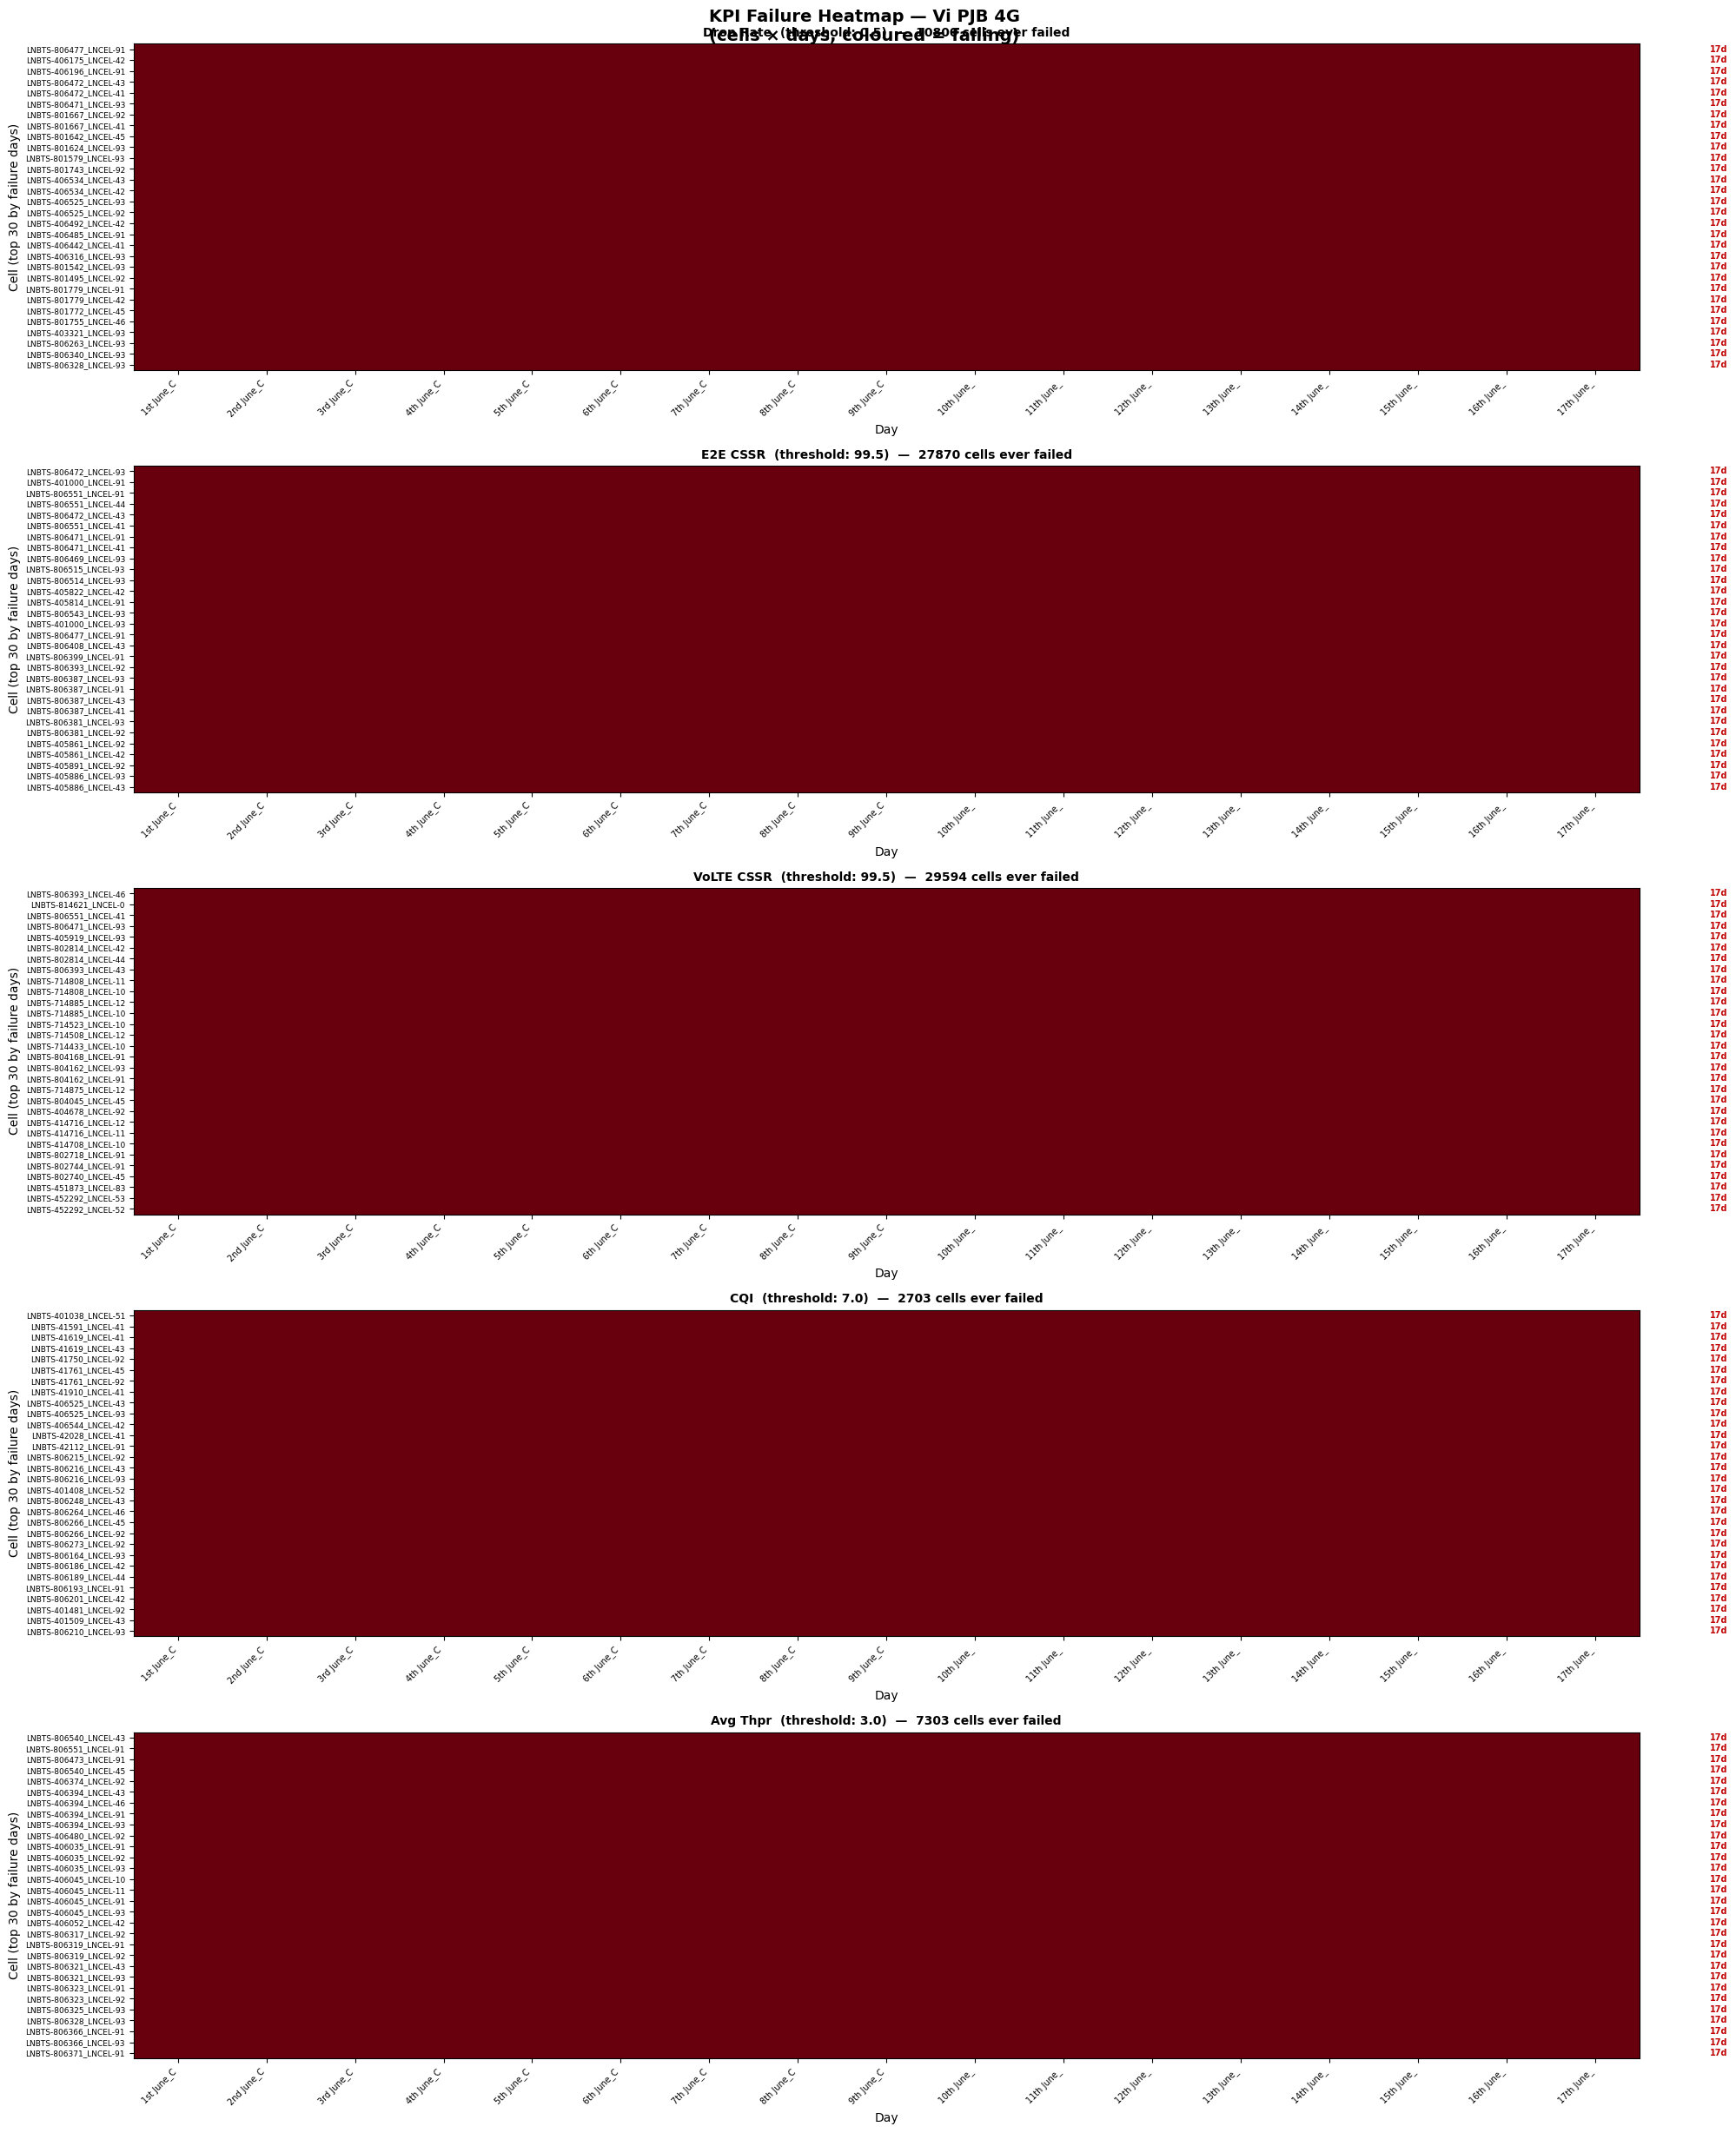

✅ Heatmap saved → outputs/kpi_failure_heatmap.png


In [8]:
# Cell 6 – Heatmap: top 30 cells × days, coloured = failing

fig, axes = plt.subplots(len(KPI_CONFIG), 1,
                          figsize=(20, 5 * len(KPI_CONFIG)))
fig.suptitle("KPI Failure Heatmap — Vi PJB 4G\n(cells × days, coloured = failing)",
             fontsize=14, fontweight="bold")

short_day_names = [s[:10] for s in sheet_names]

for ax, cfg in zip(axes, KPI_CONFIG):
    label     = cfg["label"]
    kpi_fails = failure_df[failure_df["KPI"] == label]

    if kpi_fails.empty:
        ax.set_title(f"{label} — No failures detected", fontweight="bold")
        continue

    top_cells = (
        kpi_fails.groupby("Short_Cell")
        .size()
        .sort_values(ascending=False)
        .head(30)
        .index.tolist()
    )

    matrix = pd.DataFrame(0, index=top_cells, columns=sheet_names)
    for _, rec in kpi_fails[kpi_fails["Short_Cell"].isin(top_cells)].iterrows():
        matrix.loc[rec["Short_Cell"], rec["Day"]] = 1

    im = ax.imshow(matrix.values, aspect="auto", cmap="Reds",
                   vmin=0, vmax=1, interpolation="nearest")

    ax.set_xticks(range(len(sheet_names)))
    ax.set_xticklabels(short_day_names, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(top_cells)))
    ax.set_yticklabels(matrix.index, fontsize=6.5)
    ax.set_title(f"{label}  (threshold: {cfg['threshold']})"
                 f"  —  {kpi_fails['Short_Cell'].nunique()} cells ever failed",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("Day")
    ax.set_ylabel("Cell (top 30 by failure days)")

    for i, cell in enumerate(top_cells):
        days_count = matrix.iloc[i].sum()
        ax.text(len(sheet_names) + 0.3, i,
                f"{int(days_count)}d",
                va="center", fontsize=7, color="#C00000", fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/kpi_failure_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Heatmap saved → outputs/kpi_failure_heatmap.png")

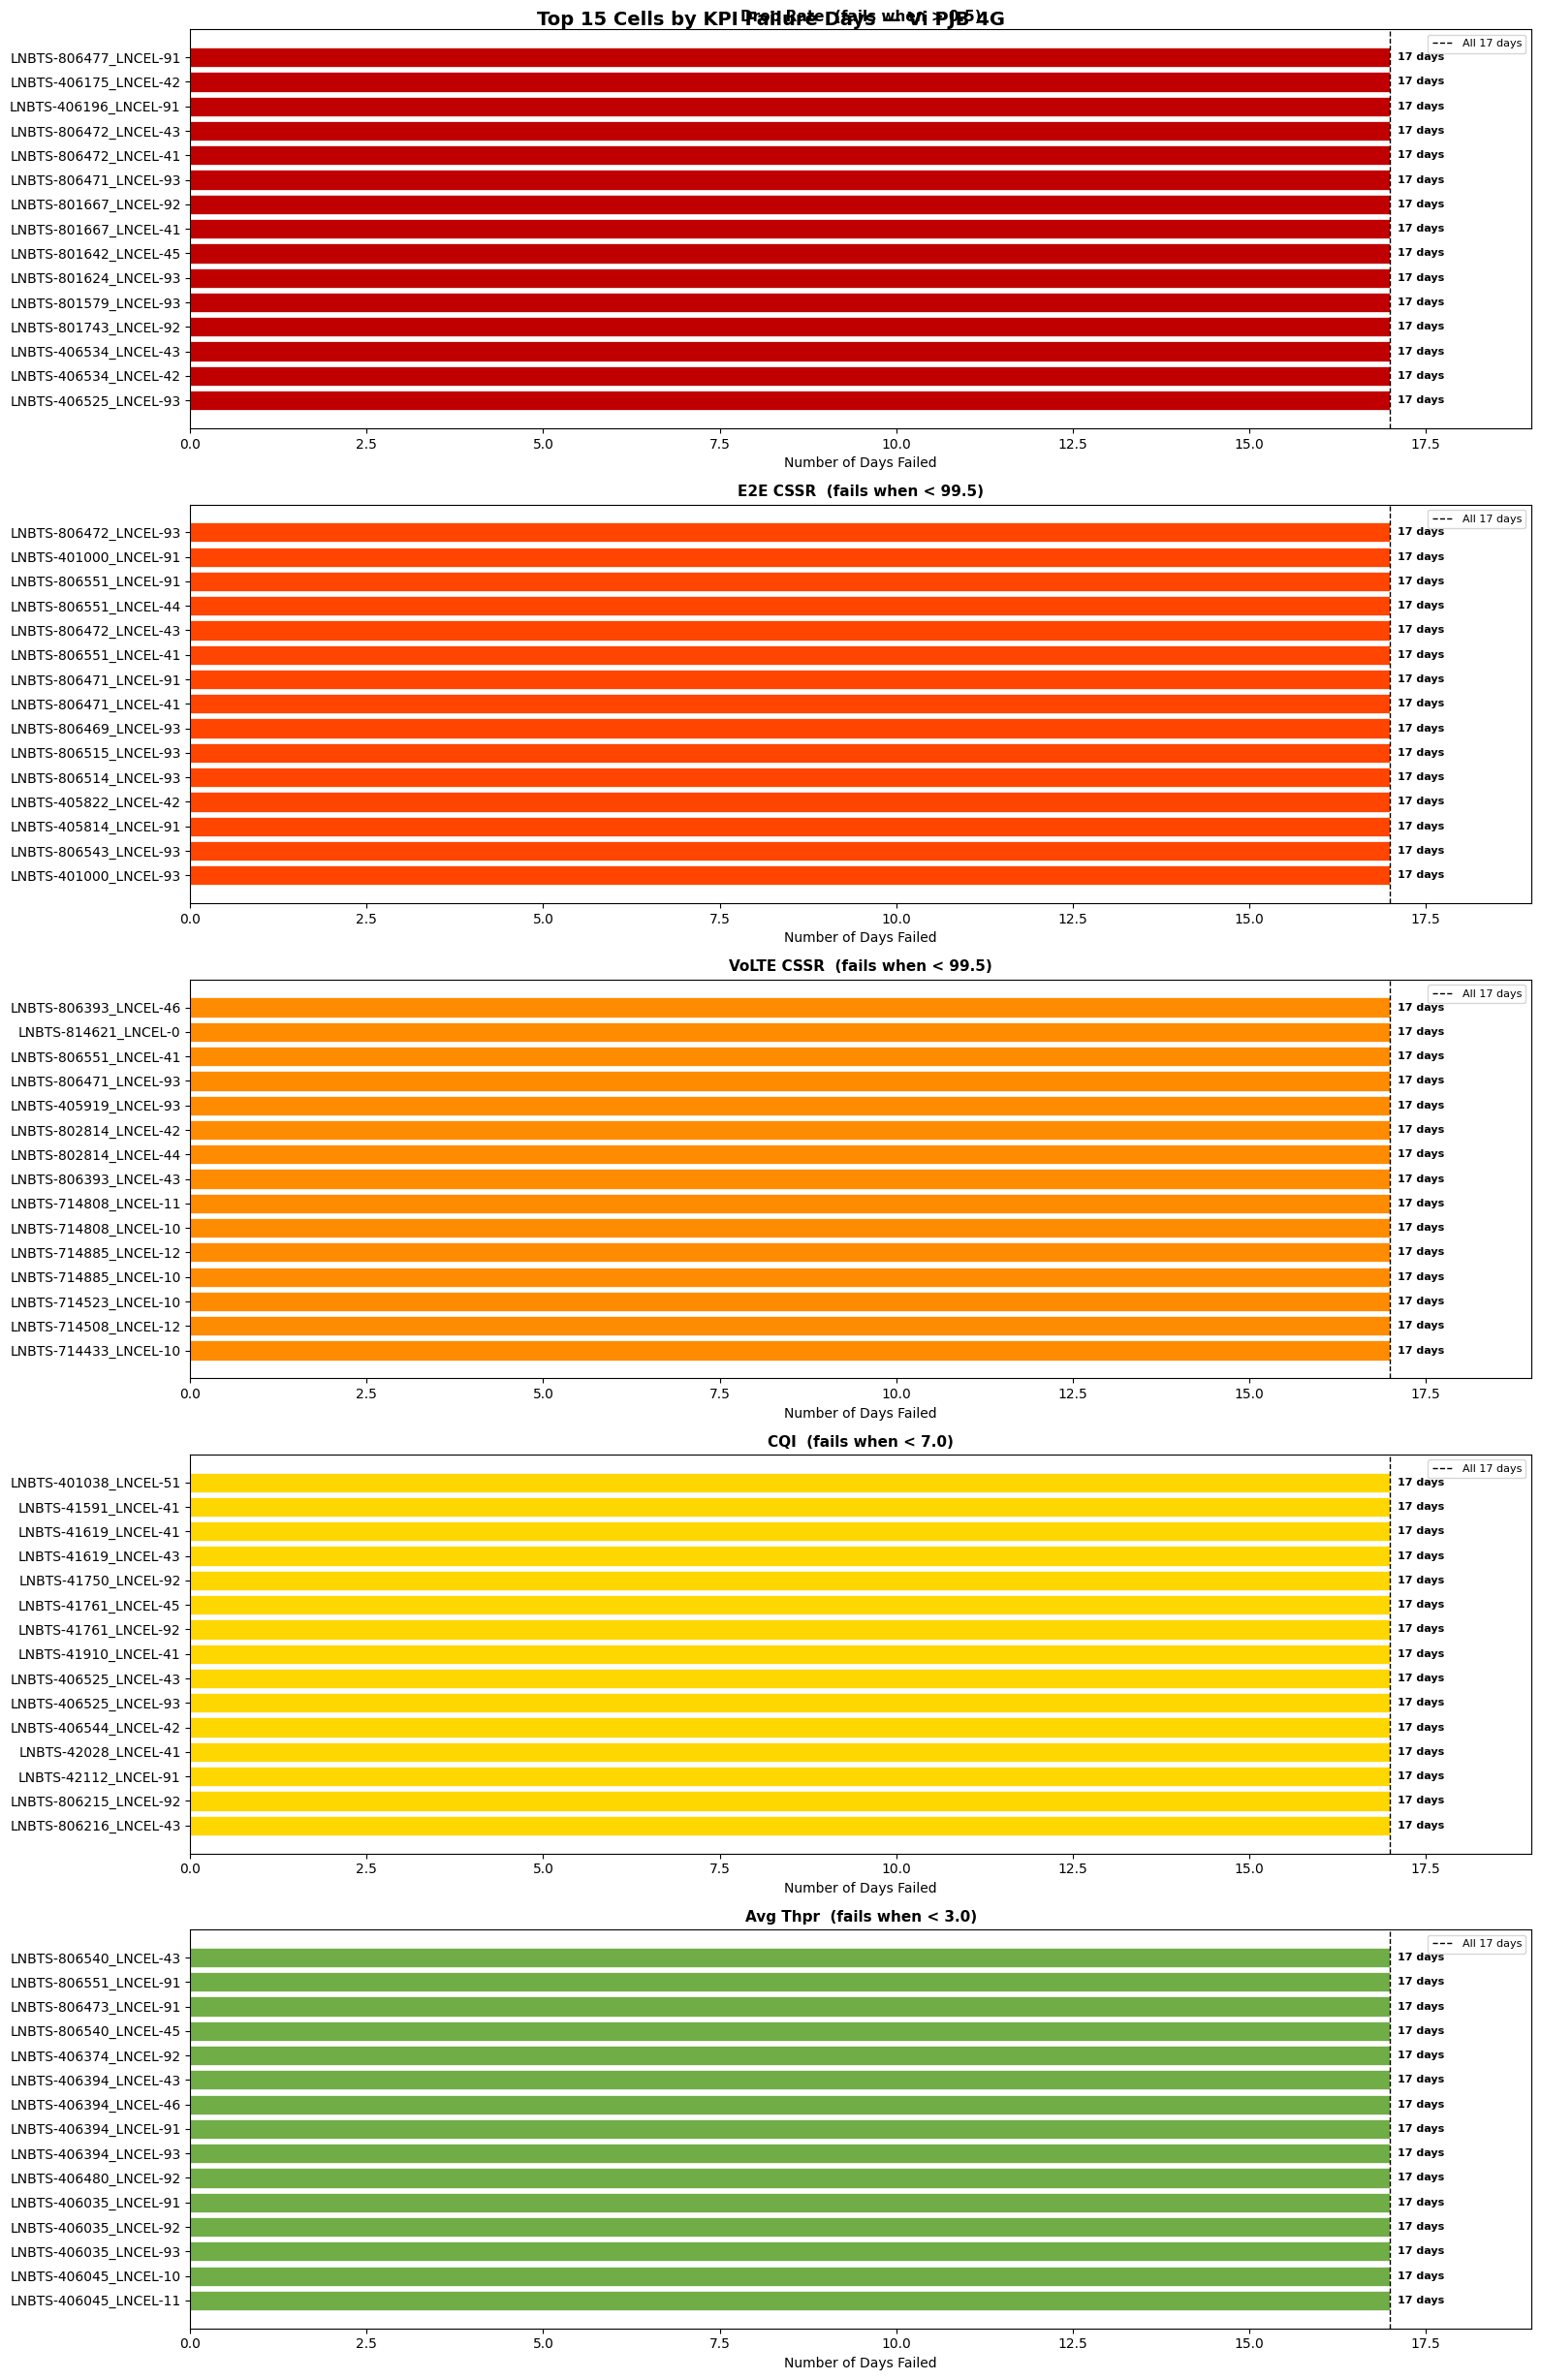

✅ Bar charts saved → outputs/kpi_top_failing_cells.png


In [9]:
# Cell 7 – Bar chart: top 15 cells with most failure days, per KPI

fig, axes = plt.subplots(len(KPI_CONFIG), 1,
                          figsize=(16, 5 * len(KPI_CONFIG)))
fig.suptitle("Top 15 Cells by KPI Failure Days — Vi PJB 4G",
             fontsize=14, fontweight="bold")

colors = ["#C00000","#FF4500","#FF8C00","#FFD700","#70AD47"]

for ax, cfg, color in zip(axes, KPI_CONFIG, colors):
    label    = cfg["label"]
    kpi_data = failure_df[failure_df["KPI"] == label]

    if kpi_data.empty:
        ax.set_title(f"{label} — No failures", fontweight="bold")
        continue

    top15 = (
        kpi_data.groupby("Short_Cell")
        .size()
        .sort_values(ascending=False)
        .head(15)
        .reset_index(name="Days_Failed")
    )

    bars = ax.barh(top15["Short_Cell"][::-1],
                   top15["Days_Failed"][::-1],
                   color=color, edgecolor="white", linewidth=0.5)

    for bar, val in zip(bars, top15["Days_Failed"][::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f"{int(val)} days", va="center", fontsize=8, fontweight="bold")

    ax.set_xlim(0, len(sheet_names) + 2)
    ax.axvline(len(sheet_names), color="black", linestyle="--",
               linewidth=1, label=f"All {len(sheet_names)} days")
    ax.set_title(f"{label}  (fails when {'>' if cfg['direction']=='high' else '<'} "
                 f"{cfg['threshold']})",
                 fontweight="bold", fontsize=11)
    ax.set_xlabel("Number of Days Failed")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/kpi_top_failing_cells.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Bar charts saved → outputs/kpi_top_failing_cells.png")

In [10]:
# Cell 8 – Export KPI_Failure_Tracker.xlsx (OPTIMIZED)
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

OUTPUT_FILE = "../outputs/KPI_Failure_Tracker.xlsx"

TTL_FILL  = PatternFill("solid", fgColor="0D2137")
TTL_FONT  = Font(bold=True, color="FFFFFF", name="Arial", size=12)
HDR_FILL  = PatternFill("solid", fgColor="1F4E79")
HDR_FONT  = Font(bold=True, color="FFFFFF", name="Arial", size=10)
ALT_FILL  = PatternFill("solid", fgColor="D6E4F0")
WHT_FILL  = PatternFill("solid", fgColor="FFFFFF")
RED_FILL  = PatternFill("solid", fgColor="FFC7CE")
BODY_FONT = Font(name="Arial", size=9)
RED_FONT  = Font(name="Arial", size=9, color="C00000", bold=True)
GRY_FONT  = Font(name="Arial", size=9, color="AAAAAA")
BLK_FONT  = Font(name="Arial", size=9, color="000000")
BLD_RED   = Font(name="Arial", size=9, color="C00000", bold=True)
BLD_BLK   = Font(name="Arial", size=9, bold=True)
THIN      = Side(style="thin", color="BFBFBF")
BORDER    = Border(left=THIN, right=THIN, top=THIN, bottom=THIN)
CENTER    = Alignment(horizontal="center", vertical="center", wrap_text=True)
LEFT      = Alignment(horizontal="left",   vertical="center", wrap_text=True)
max_days  = len(sheet_names)

FILL_CACHE = {}
for d in range(0, max_days + 1):
    if d == 0:
        FILL_CACHE[d] = WHT_FILL
    else:
        intensity     = int((d / max_days) * 200)
        green         = max(0, 255 - intensity)
        blue          = max(0, 255 - intensity)
        FILL_CACHE[d] = PatternFill("solid", fgColor=f"FF{green:02X}{blue:02X}")

def days_fill(days): return FILL_CACHE.get(int(days), WHT_FILL)
def days_font(days):
    if days == 0:              return GRY_FONT
    if days >= max_days * 0.8: return RED_FONT
    return BLK_FONT

def write_title_header(ws, title, headers):
    ncols = len(headers)
    ws.append([title] + [""] * (ncols - 1))
    ws.merge_cells(f"A1:{get_column_letter(ncols)}1")
    ws["A1"].fill = TTL_FILL; ws["A1"].font = TTL_FONT
    ws["A1"].alignment = CENTER; ws["A1"].border = BORDER
    ws.append(headers)
    for cell in ws[2]:
        cell.fill = HDR_FILL; cell.font = HDR_FONT
        cell.alignment = CENTER; cell.border = BORDER
    ws.row_dimensions[1].height = 22
    ws.row_dimensions[2].height = 28

def apply_base_style(ws, start_row, end_row, ncols):
    for i in range(start_row, end_row + 1):
        fill = ALT_FILL if i % 2 == 0 else None
        for j in range(1, ncols + 1):
            c = ws.cell(row=i, column=j)
            c.font      = BODY_FONT
            c.border    = BORDER
            c.alignment = LEFT if j == 1 else CENTER
            if fill: c.fill = fill

wb = Workbook()
wb.remove(wb.active)

# ══════════════════════════════════════════
# Sheet 1 — KPI Summary
# ══════════════════════════════════════════
print("Writing KPI Summary...")
s1 = wb.create_sheet("KPI Summary")
s1_headers = ["KPI", "Threshold", "Cells Ever Failed",
              "Total Failure Events", "Avg Days Failed",
              "Max Days (1 Cell)", "Cells Failed All Days",
              "Worst Cell", "Worst Cell Days"]
write_title_header(s1, "KPI Failure Summary — Vi PJB 4G", s1_headers)

for _, row in kpi_summary_df.iterrows():
    s1.append([
        row["KPI"], row["Threshold"], row["Cells_Ever_Failed"],
        row["Total_Failure_Events"],  round(row["Avg_Days_Failed"]),
        row["Max_Days_By_One_Cell"], row["Cells_Failed_All_Days"],
        row["Worst_Cell"], row["Worst_Cell_Days"],
    ])

apply_base_style(s1, 3, 3 + len(kpi_summary_df) - 1, len(s1_headers))
for col, w in zip("ABCDEFGHI", [16,12,18,20,16,18,20,28,16]):
    s1.column_dimensions[col].width = w
s1.freeze_panes = "A3"

# ══════════════════════════════════════════
# Sheet 2 — Full Failure Matrix
# ══════════════════════════════════════════
print("Writing Failure Matrix...")
s2 = wb.create_sheet("Failure Matrix")
matrix_headers = (
    ["Cell ID (eNodeB_Cell)"] + kpi_cols_present +
    ["Total Failure Days", "KPIs Ever Failed", "Max Days Any KPI"]
)
write_title_header(s2, "KPI Failure Matrix — Days Failed per Cell per KPI", matrix_headers)

pivot_vals = kpi_pivot[kpi_cols_present].values.astype(int)
short_vals = kpi_pivot["Short_Cell"].values
total_vals = kpi_pivot["Total_KPI_Failures"].astype(int).values
ever_vals  = kpi_pivot["KPIs_Ever_Failed"].astype(int).values
max_vals   = kpi_pivot["Max_Days_Any_KPI"].astype(int).values

for idx in range(len(kpi_pivot)):
    row_data = (
        [short_vals[idx]] +
        list(pivot_vals[idx]) +
        [total_vals[idx], ever_vals[idx], max_vals[idx]]
    )
    s2.append(row_data)

apply_base_style(s2, 3, 3 + len(kpi_pivot) - 1, len(matrix_headers))

n_kpis = len(kpi_cols_present)
for idx in range(len(kpi_pivot)):
    row_i = idx + 3
    for k in range(n_kpis):
        val  = pivot_vals[idx][k]
        cell = s2.cell(row=row_i, column=k + 2)
        cell.fill = days_fill(val)
        cell.font = days_font(val)
    total_col = n_kpis + 2
    total_val = total_vals[idx]
    s2.cell(row=row_i, column=total_col).font = (
        BLD_RED if total_val >= max_days * 2 else BLD_BLK
    )

s2.column_dimensions["A"].width = 24
for idx in range(2, len(matrix_headers) + 1):
    s2.column_dimensions[get_column_letter(idx)].width = 16
s2.freeze_panes = "B3"

# ══════════════════════════════════════════
# Sheets 3–7 — One sheet per KPI
# ══════════════════════════════════════════
for cfg in KPI_CONFIG:
    label    = cfg["label"]
    print(f"Writing KPI sheet: {label}...")
    kpi_data = failure_df[failure_df["KPI"] == label]

    if kpi_data.empty:
        print(f"  No failures found for {label}, skipping")
        continue

    per_cell = (
        kpi_data.groupby("Short_Cell")
        .agg(
            Days_Failed=("Day",   "count"),
            Avg_Value  =("Value", "mean"),
            Min_Value  =("Value", "min"),
            Max_Value  =("Value", "max"),
        )
        .reset_index()
        .sort_values("Days_Failed", ascending=False)
        .reset_index(drop=True)
    )
    per_cell["Persistence_%"] = (per_cell["Days_Failed"] / max_days * 100).round(1)

    safe_label = label[:31].replace("/", "-")
    ws = wb.create_sheet(title=safe_label)

    kpi_headers = (
        ["Cell ID (eNodeB_Cell)", "Days Failed", "Persistence %",
         f"Avg {label}", f"Min {label}", f"Max {label}"]
        + [s[:12] for s in sheet_names]
    )
    write_title_header(ws,
        f"{label} Failures — Threshold "
        f"{'>' if cfg['direction']=='high' else '<'}{cfg['threshold']}  "
        f"({int(per_cell['Days_Failed'].sum())} failure-days, "
        f"{len(per_cell)} cells)",
        kpi_headers
    )

    day_pivot = kpi_data.pivot_table(
        index   = "Short_Cell",
        columns = "Day",
        values  = "Value",
        aggfunc = "first"
    ).reindex(columns=sheet_names)

    days_failed = []

    for idx in range(len(per_cell)):
        p_row    = per_cell.iloc[idx]
        cell_id  = p_row["Short_Cell"]
        df_val   = int(p_row["Days_Failed"])
        days_failed.append(df_val)

        ws_row = [
            cell_id,
            df_val,
            f"{p_row['Persistence_%']}%",
            round(p_row["Avg_Value"], 3),
            round(p_row["Min_Value"], 3),
            round(p_row["Max_Value"], 3),
        ]
        if cell_id in day_pivot.index:
            day_vals = day_pivot.loc[cell_id]
            for v in day_vals:
                ws_row.append(round(float(v), 3) if pd.notna(v) else "")
        else:
            ws_row += [""] * len(sheet_names)

        ws.append(ws_row)

    n_rows  = len(per_cell)
    n_cols  = len(kpi_headers)
    apply_base_style(ws, 3, 3 + n_rows - 1, n_cols)

    for idx in range(n_rows):
        row_i  = idx + 3
        df_val = days_failed[idx]
        cell_id = per_cell.iloc[idx]["Short_Cell"]

        ws.cell(row=row_i, column=2).fill = days_fill(df_val)
        ws.cell(row=row_i, column=2).font = days_font(df_val)

        if cell_id in day_pivot.index:
            day_vals = day_pivot.loc[cell_id].values
            for k, v in enumerate(day_vals):
                if pd.notna(v):
                    c = ws.cell(row=row_i, column=7 + k)
                    c.fill = RED_FILL
                    c.font = RED_FONT

    ws.column_dimensions["A"].width = 24
    for idx in range(2, 7):
        ws.column_dimensions[get_column_letter(idx)].width = 14
    for idx in range(7, 7 + len(sheet_names)):
        ws.column_dimensions[get_column_letter(idx)].width = 12
    ws.freeze_panes = "G3"

print("Saving...")
os.makedirs(os.path.dirname(OUTPUT_FILE), exist_ok=True)
wb.save(OUTPUT_FILE)
print(f"\n✅ Report saved → {OUTPUT_FILE}")
print(f"   Sheets: KPI Summary + Failure Matrix + {len(KPI_CONFIG)} KPI sheets")

Writing KPI Summary...
Writing Failure Matrix...
Writing KPI sheet: Drop Rate...
Writing KPI sheet: E2E CSSR...
Writing KPI sheet: VoLTE CSSR...
Writing KPI sheet: CQI...
Writing KPI sheet: Avg Thpr...
Saving...

✅ Report saved → ../outputs/KPI_Failure_Tracker.xlsx
   Sheets: KPI Summary + Failure Matrix + 5 KPI sheets


import pyxlsb
import pandas as pd

file_path = r"../data/your_sample_file.xlsb"  # path to the 7-sheet file

with pyxlsb.open_workbook(file_path) as wb:
    sheet_names = wb.sheets

df = pd.read_excel(file_path, sheet_name=sheet_names[0], engine="pyxlsb")

# Find VoLTE related columns
volte_cols = [c for c in df.columns if "volte" in str(c).lower() or "VoLTE" in str(c)]
cssr_cols  = [c for c in df.columns if "cssr" in str(c).lower() or "setup" in str(c).lower()]

print("VoLTE columns:")
for c in volte_cols:
    print(f"  {c}")

print("\nCSSR columns:")
for c in cssr_cols:
    print(f"  {c}")

In [11]:
import pyxlsb
import pandas as pd

file_path = r"../data/your_sample_file.xlsb"  # path to the 7-sheet file

with pyxlsb.open_workbook(file_path) as wb:
    sheet_names = wb.sheets

df = pd.read_excel(file_path, sheet_name=sheet_names[0], engine="pyxlsb")

# Find VoLTE related columns
volte_cols = [c for c in df.columns if "volte" in str(c).lower() or "VoLTE" in str(c)]
cssr_cols  = [c for c in df.columns if "cssr" in str(c).lower() or "setup" in str(c).lower()]

print("VoLTE columns:")
for c in volte_cols:
    print(f"  {c}")

print("\nCSSR columns:")
for c in cssr_cols:
    print(f"  {c}")

FileNotFoundError: [Errno 2] No such file or directory: '../data/your_sample_file.xlsb'

In [12]:
import pandas as pd

file_path = r"C:\Users\irina\Downloads\samplefile.xlsx"

xl = pd.ExcelFile(file_path)
print(f"Sheets: {xl.sheet_names}")

df = pd.read_excel(file_path, sheet_name=xl.sheet_names[0])

volte_cols = [c for c in df.columns if "volte" in str(c).lower()]
cssr_cols  = [c for c in df.columns if "cssr" in str(c).lower()
              or "setup" in str(c).lower()]
drop_cols  = [c for c in df.columns if "drop" in str(c).lower()]
cqi_cols   = [c for c in df.columns if "cqi" in str(c).lower()]
thpr_cols  = [c for c in df.columns if "thp" in str(c).lower()
              or "throughput" in str(c).lower()]

print("\nVoLTE columns:")
for c in volte_cols: print(f"  {c}")

print("\nCSSR/Setup columns:")
for c in cssr_cols: print(f"  {c}")

print("\nDrop columns:")
for c in drop_cols: print(f"  {c}")

print("\nCQI columns:")
for c in cqi_cols: print(f"  {c}")

print("\nThroughput columns:")
for c in thpr_cols: print(f"  {c}")

Sheets: ['Sheet1', 'Sheet2', 'Sheet3', 'Sheet4', 'Sheet5', 'Sheet6', 'Sheet7']

VoLTE columns:
  Nokia_Volte_Drop_NOM_New_VODA
  Nokia_Volte_Drop_DNOM_New_VODA
  VoLTE Call Setup Success Rate_Nokia_VeMr
  Nokia_LTE_VoLTE Traffic Erl
  VoLTE Drop Call Rate_Nokia_VeMr
  IDEA_VoLTE_Total-Traffic_Erl
  VoLTE Call Setup Success Rate_NBHD_Nokia_VeMr
  Nokia_LTE_VoLTE Traffic KErl
  MV_VoLTE Handover Execution Success Rate_Intra_Inter_QCI1
  4G-Count of VoLTE DCR>2% 
  4G-count of VoLTE_DCR>5%
  VOLTE HOSR EXE FAILS
  MV_VoLTE Handover Preparation Success Rate _Intra_Inter_QCI1
  MV_VoLTE Handover Preparation Success Rate _Intra_Inter_QCI1_Nom
  MV_VoLTE Handover Preparation Success Rate _Intra_Inter_QCI1_Denom

CSSR/Setup columns:
  E2E Call Setup Success Rate_Nokia_VeMr
  VoLTE Call Setup Success Rate_Nokia_VeMr
  VoLTE Call Setup Success Rate_NBHD_Nokia_VeMr
  LEPSB.ERAB_INI_SETUP_FAIL_TNL_TRU

Drop columns:
  Nokia_Volte_Drop_NOM_New_VODA
  Nokia_Volte_Drop_DNOM_New_VODA
  VoLTE Drop Call

In [13]:
import pandas as pd

file_path = r"C:\Users\irina\Downloads\samplefile.xlsx"
xl = pd.ExcelFile(file_path)

df = pd.read_excel(file_path, sheet_name=xl.sheet_names[0])

col = "VoLTE Call Setup Success Rate_Nokia_VeMr"
print(f"Column: {col}")
print(f"Non-null values: {df[col].notna().sum()}")
print(f"Null values    : {df[col].isna().sum()}")
print(f"Sample values  : {df[col].dropna().head(10).tolist()}")
print(f"Min: {df[col].min()}  Max: {df[col].max()}")

Column: VoLTE Call Setup Success Rate_Nokia_VeMr
Non-null values: 48553
Null values    : 226
Sample values  : [99.53, 100.0, 100.0, 100.0, 99.9, 99.81, 99.78, 99.59, 99.86, 99.75]
Min: 0.0  Max: 101.23


In [14]:
import pandas as pd

file_path = r"C:\Users\irina\Downloads\samplefile.xlsx"
xl = pd.ExcelFile(file_path)

df = pd.read_excel(file_path, sheet_name=xl.sheet_names[0])

col = "VoLTE Call Setup Success Rate_Nokia_VeMr"

# How many cells actually breach the threshold of < 99%
below_99 = df[col] < 99
zero_vals = df[col] == 0

print(f"Total rows          : {len(df)}")
print(f"Values below 99%    : {below_99.sum()}")
print(f"Values equal to 0   : {zero_vals.sum()}")
print(f"\nDistribution:")
print(f"  >= 99%  (passing) : {(df[col] >= 99).sum()}")
print(f"  < 99%   (failing) : {below_99.sum()}")
print(f"  == 0    (dead)    : {zero_vals.sum()}")
print(f"\nFailing values sample:")
print(df[col][below_99].head(20).tolist())

Total rows          : 48779
Values below 99%    : 1813
Values equal to 0   : 31

Distribution:
  >= 99%  (passing) : 46740
  < 99%   (failing) : 1813
  == 0    (dead)    : 31

Failing values sample:
[96.55, 0.0, 98.72, 0.0, 0.0, 96.92, 98.7, 98.62, 98.71, 98.65, 97.84, 96.55, 97.05, 98.9, 98.97, 98.7, 98.78, 98.96, 98.98, 97.82]


In [15]:
import pandas as pd

file_path = r"C:\Users\irina\Downloads\samplefile.xlsx"
xl        = pd.ExcelFile(file_path)

col = "VoLTE Call Setup Success Rate_Nokia_VeMr"

# Check failures per sheet
for sheet in xl.sheet_names:
    df      = pd.read_excel(file_path, sheet_name=sheet)
    numeric = pd.to_numeric(df[col], errors="coerce")
    fails   = (numeric < 99).sum()
    print(f"  {sheet}: {fails} failures out of {len(df)} rows")

  Sheet1: 1813 failures out of 48779 rows
  Sheet2: 30 failures out of 31 rows
  Sheet3: 1835 failures out of 48796 rows
  Sheet4: 2091 failures out of 49876 rows
  Sheet5: 1886 failures out of 49795 rows
  Sheet6: 1863 failures out of 49733 rows
  Sheet7: 2082 failures out of 49874 rows
